# 조합3(11개 변수) 밖에서 새로운 사기 패턴 찾기

## 배경

지금 쓰는 11개 변수(`amt_zscore_card`, `amt_to_prior_median_ratio`,
`prior_normal_median_amt`, `rolling_sum_amt_1h`, `recent_24h_high_amt_count` 등)는
대부분 **"그 카드의 평소 금액 대비 얼마나 벗어났는가"**를 재는 변수다. 하지만 실제
FN(놓친 사기)은 반드시 "평소 금액에서 벗어난 거래"로 나타나지 않을 수 있다 —
금액은 평범한데 위치가 이상하거나, 처음 보는 가맹점을 갑자기 여러 곳 쓰거나,
카드 발급 직후이거나, 짧은 시간에 몰아서 결제하는 식으로 **다른 형태**로 나타날 수
있다.

이 노트북은 raw 데이터(23개 컬럼)에서 amt 편차 이외의 축으로 사기율을 다각도로
뜯어보고 시각화한다. 11개 변수는 건드리지 않고, **탐색 전용**이다.

## 다루는 6개 축

| 구분 | 축 | 기존 11개 변수와의 차이 |
|---|---|---|
| A | 시간 · 계정 나이 | 요일×업종, 거래 간격, 카드 사용 경과일 (금액 무관) |
| B | 지리 | 자택-가맹점 거리, 같은 날 최대 이동거리 (속도 아닌 거리 자체) |
| C | 가맹점·업종 다양성 | 하루 이용 가맹점 수, 가맹점 최초이용 여부, 가맹점별 사기 집중도 |
| D | 인구통계 | 도시 인구밀도, 직업, 연령×성별×업종 3중 코호트 |
| E | 금액의 절대적 형태 | 라운드넘버 금액, 소액→고액 카드테스트 시퀀스 (개인 편차 아님) |
| F | 연속거래 | 10분 이내 재결제 여부 |

## 함께 드리는 SQL

같은 6개 축을 MySQL 8.0(`transactions` 테이블, 강의에서 쓰던 것과 동일 스타일)
쿼리로도 `new_pattern_analysis.sql`에 정리해 뒀다. SQL은 실제 MariaDB에 합성
데이터를 올려서 문법·실행까지 확인했다. 이 노트북은 raw csv를 pandas로 바로
읽어서 같은 걸 계산하는 버전 — SQL 없이도 바로 돌릴 수 있고, SQL 결과와
교차검증하는 용도로도 쓸 수 있다.

## 사용법

1. `build_leakfree_features.ipynb`를 실행한 폴더(= raw csv 경로를 아는 폴더)에
   이 노트북을 두고 위에서부터 순서대로 실행(Run All)한다.
2. 결과: `new_pattern_eda_outputs/` 폴더에 구간별 사기율 표(csv)와 막대그래프(png)가
   저장된다. 표는 콘솔에도 그대로 출력된다.
3. **주의**: 여기 나오는 수치는 코드 검증을 위해 작은 합성 데이터로 미리
   실행해본 것이라, 실제 185만 건 raw 데이터로 돌리면 완전히 다른(훨씬 의미
   있는) 숫자가 나온다. "코드가 도는지"만 미리 확인했다고 보면 된다.


## 0. 경로 설정 및 공통 유틸 함수

In [1]:
from __future__ import annotations

import itertools
from pathlib import Path

import matplotlib
import matplotlib.font_manager
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.unicode_minus"] = False
for _font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if _font in {f.name for f in matplotlib.font_manager.fontManager.ttflist}:
        plt.rcParams["font.family"] = _font
        break
# 위 3개 폰트가 하나도 없으면(리눅스 등) 한글이 네모(tofu)로 보일 수 있음 -> 그림 해석엔 문제 없음

SCRIPT_DIR = Path.cwd()
OUT_DIR = SCRIPT_DIR / "new_pattern_eda_outputs"
OUT_DIR.mkdir(exist_ok=True)

BAR_COLOR = "#4C72B0"

CANDIDATE_TRAIN_PATHS = [
    Path(r"C:\\Users\\splen\\OneDrive\\Desktop\\BDAI_\\BOOSTMAP\\Fraud-FDS-Project\\data\\raw\\fraudTrain.csv"),
    Path(r"C:\\Users\\splen\\OneDrive\\Desktop\\BDAI\\BOOSTMAP\\Fraud-FDS-Project\\data\\raw\\fraudTrain.csv"),
    SCRIPT_DIR / "data" / "raw" / "fraudTrain.csv",
    SCRIPT_DIR / "fraudTrain.csv",
]
CANDIDATE_TEST_PATHS = [
    Path(r"C:\\Users\\splen\\OneDrive\\Desktop\\BDAI_\\BOOSTMAP\\Fraud-FDS-Project\\data\\raw\\fraudTest.csv"),
    Path(r"C:\\Users\\splen\\OneDrive\\Desktop\\BDAI\\BOOSTMAP\\Fraud-FDS-Project\\data\\raw\\fraudTest.csv"),
    SCRIPT_DIR / "data" / "raw" / "fraudTest.csv",
    SCRIPT_DIR / "fraudTest.csv",
]


def find_path(candidates: list[Path]) -> Path:
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        "raw csv를 찾지 못했습니다. CANDIDATE_TRAIN_PATHS/CANDIDATE_TEST_PATHS 경로를 확인해주세요.\\n"
        + "\\n".join(str(p) for p in candidates)
    )


def haversine(lat1, lon1, lat2, lon2):
    r = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2) ** 2 + np.cos(p1) * np.cos(p2) * np.sin(dlambda / 2) ** 2
    return 2 * r * np.arcsin(np.sqrt(a))


def exact_age(trans_dt: pd.Series, birth_dt: pd.Series) -> pd.Series:
    years = trans_dt.dt.year - birth_dt.dt.year
    not_yet = (trans_dt.dt.month < birth_dt.dt.month) | (
        (trans_dt.dt.month == birth_dt.dt.month) & (trans_dt.dt.day < birth_dt.dt.day)
    )
    return (years - not_yet.astype("int64")).astype("int64")


def load_raw(path: Path, source: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="raise")
    df["dob"] = pd.to_datetime(df["dob"], errors="raise")
    df["age"] = exact_age(df["trans_date_trans_time"], df["dob"])
    df["_source"] = source
    return df


def fraud_table(df: pd.DataFrame, group_cols: list[str], min_count: int = 5) -> pd.DataFrame:
    g = df.groupby(group_cols, observed=True).agg(
        tx_cnt=("is_fraud", "size"), fraud_cnt=("is_fraud", "sum"), fraud_rate=("is_fraud", "mean"),
    ).reset_index()
    g = g[g["tx_cnt"] >= min_count].copy()
    g["fraud_pct"] = (g["fraud_rate"] * 100).round(4)
    overall = df["is_fraud"].mean()
    g["lift_vs_overall"] = (g["fraud_rate"] / overall).round(2) if overall > 0 else np.nan
    return g.sort_values("fraud_pct", ascending=False)


def bar_chart(labels, values, title, ylabel, path, color=BAR_COLOR, rotate=0):
    fig, ax = plt.subplots(figsize=(max(6, len(labels) * 0.5), 4.5))
    ax.bar(range(len(labels)), values, color=color)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=rotate, ha="right" if rotate else "center")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    fig.savefig(path)
    plt.show()


## 1. 데이터 로드

In [2]:
train_path = find_path(CANDIDATE_TRAIN_PATHS)
test_path = find_path(CANDIDATE_TEST_PATHS)
print(f"train: {train_path.resolve()}")
print(f"test : {test_path.resolve()}")

train = load_raw(train_path, "train")
test = load_raw(test_path, "test")
df = pd.concat([train, test], ignore_index=True)
df = df.sort_values(["cc_num", "trans_date_trans_time", "trans_num"], kind="mergesort").reset_index(drop=True)
df["dow"] = df["trans_date_trans_time"].dt.day_name()
df["age_bucket"] = pd.cut(
    df["age"], bins=[0, 20, 30, 40, 50, 60, 200],
    labels=["~20대", "20대", "30대", "40대", "50대", "60대+"], right=False,
)

print(f"전체 행 수: {len(df):,} / 전체 사기율: {df['is_fraud'].mean()*100:.4f}%")
df.head(3)


train: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTrain.csv
test : C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTest.csv
전체 행 수: 1,852,394 / 전체 사기율: 0.5210%


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,_source,dow,age_bucket
0,2019-01-01 12:47:15,60416207185,"fraud_Jones, Sawayn and Romaguera",misc_net,7.27,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,...,1986-02-17,98e3dcf98101146a577f85a34e58feec,1325422035,43.974711,-109.741904,0,32,train,Tuesday,30대
1,2019-01-02 08:44:57,60416207185,fraud_Berge LLC,gas_transport,52.94,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,...,1986-02-17,498120fc45d277f7c88e3dba79c33865,1325493897,42.018766,-109.044172,0,32,train,Wednesday,30대
2,2019-01-02 08:47:36,60416207185,fraud_Luettgen PLC,gas_transport,82.08,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,...,1986-02-17,95f514bb993151347c7acdf8505c3d62,1325494056,42.961335,-109.157564,0,32,train,Wednesday,30대


## A. 시간 · 계정 나이(tenure) 패턴

- **A1**: 요일 x 업종 조합 중 사기율이 튀는 곳이 있는가 (단순 "심야" 말고 요일+업종 조합)
- **A2**: 카드별 직전 거래와의 시간 간격 — 아주 촘촘하게 붙어 있는 거래(버스트)나 반대로
  오래 쉬다가 갑자기 움직인 거래가 위험한가
- **A3**: 그 카드의 첫 거래로부터 며칠 지났는가 — 신규 카드(계정 나이가 어릴수록)가
  더 위험한가

In [3]:
# A1. 요일 x 업종
t_a1 = fraud_table(df, ["dow", "category"], min_count=30)
t_a1.to_csv(OUT_DIR / "A1_dow_category_fraud.csv", index=False, encoding="utf-8-sig")
print("[A1] 요일 x 업종 사기율 TOP 10")
t_a1.head(10)


[A1] 요일 x 업종 사기율 TOP 10


,dow,category,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
67,Thursday,shopping_net,15337,302,0.019691,1.9691,3.78
11,Friday,shopping_net,16214,314,0.019366,1.9366,3.72
95,Wednesday,shopping_net,13806,265,0.019195,1.9195,3.68
64,Thursday,misc_net,10232,188,0.018374,1.8374,3.53
39,Saturday,shopping_net,19733,312,0.015811,1.5811,3.03
88,Wednesday,grocery_pos,17632,273,0.015483,1.5483,2.97
4,Friday,grocery_pos,20838,322,0.015453,1.5453,2.97
8,Friday,misc_net,10491,162,0.015442,1.5442,2.96
60,Thursday,grocery_pos,20041,309,0.015418,1.5418,2.96
53,Sunday,shopping_net,26054,399,0.015314,1.5314,2.94


[A2] 직전 거래 간격 구간별 사기율


,gap_bucket,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
1,1_1분이내,6361,143,0.022481,2.2481,4.31
2,2_10분이내,54487,1019,0.018702,1.8702,3.59
3,3_1시간이내,257237,3031,0.011783,1.1783,2.26
6,6_1주일초과,319,2,0.006270,0.6270,1.20
4,4_1일이내,1391077,5082,0.003653,0.3653,0.70
5,5_1주일이내,141870,283,0.001995,0.1995,0.38
0,0_첫거래,44,0,0.000000,0.0000,0.00


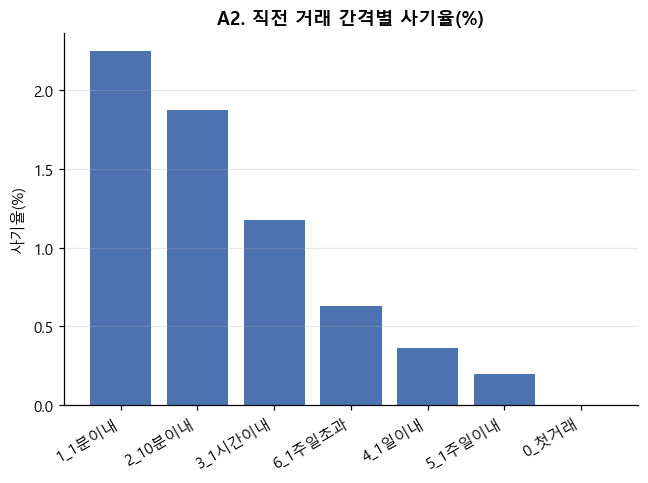

In [4]:
# A2. 카드별 직전 거래와의 간격
gap = df.groupby("cc_num")["trans_date_trans_time"].diff().dt.total_seconds()
bins = [-1, 0, 60, 600, 3600, 86400, 604800, np.inf]
labels = ["0_첫거래", "1_1분이내", "2_10분이내", "3_1시간이내", "4_1일이내", "5_1주일이내", "6_1주일초과"]
gap_bucket = pd.cut(gap.fillna(-1), bins=bins, labels=labels)
tmp = pd.DataFrame({"gap_bucket": gap_bucket, "is_fraud": df["is_fraud"]})
t_a2 = fraud_table(tmp, ["gap_bucket"], min_count=1)
t_a2.to_csv(OUT_DIR / "A2_gap_bucket_fraud.csv", index=False, encoding="utf-8-sig")
print("[A2] 직전 거래 간격 구간별 사기율")
display(t_a2)
bar_chart(t_a2["gap_bucket"].astype(str), t_a2["fraud_pct"],
          "A2. 직전 거래 간격별 사기율(%)", "사기율(%)", OUT_DIR / "A2_gap_bucket_fraud.png", rotate=30)


[A3] 카드 사용 경과일 구간별 사기율


,tenure_bucket,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
0,0_당일(첫거래),3478,574,0.165037,16.5037,31.68
1,1_1주이내,12362,419,0.033894,3.3894,6.51
2,2_1개월이내,38259,388,0.010141,1.0141,1.95
3,3_3개월이내,123673,821,0.006638,0.6638,1.27
4,4_3개월초과,1674622,7449,0.004448,0.4448,0.85


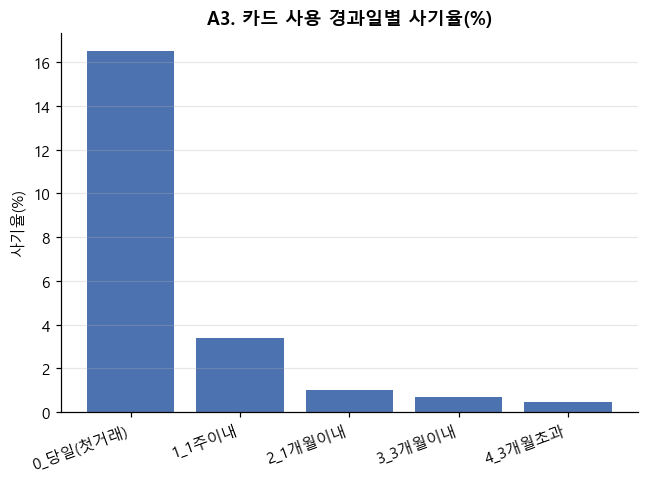

In [5]:
# A3. 카드 최초거래 이후 경과일
first_dt = df.groupby("cc_num")["trans_date_trans_time"].transform("min")
days_since = (df["trans_date_trans_time"] - first_dt).dt.days
tenure_bucket = pd.cut(
    days_since, bins=[-1, 0, 7, 30, 90, np.inf],
    labels=["0_당일(첫거래)", "1_1주이내", "2_1개월이내", "3_3개월이내", "4_3개월초과"],
)
tmp = pd.DataFrame({"tenure_bucket": tenure_bucket, "is_fraud": df["is_fraud"]})
t_a3 = fraud_table(tmp, ["tenure_bucket"], min_count=1)
t_a3.to_csv(OUT_DIR / "A3_tenure_fraud.csv", index=False, encoding="utf-8-sig")
print("[A3] 카드 사용 경과일 구간별 사기율")
display(t_a3)
bar_chart(t_a3["tenure_bucket"].astype(str), t_a3["fraud_pct"],
          "A3. 카드 사용 경과일별 사기율(%)", "사기율(%)", OUT_DIR / "A3_tenure_fraud.png", rotate=20)


## B. 지리 패턴

- **B1**: 자택(lat/long)-가맹점(merch_lat/merch_long) 실제 거리(km) 자체 (속도 아님)
- **B3**: 카드별 같은 날 안에서 가장 멀리 떨어진 두 결제지점 사이의 거리 — 하루 안에
  물리적으로 멀리 떨어진 곳들을 오갔는가

[B1] 자택-가맹점 거리 구간별 사기율


,dist_bucket,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
3,3_50-80km,589403,3139,0.005326,0.5326,1.02
4,4_80-100km,451392,2352,0.005211,0.5211,1.00
5,5_100km이상,432680,2242,0.005182,0.5182,0.99
2,2_30-50km,242692,1242,0.005118,0.5118,0.98
1,1_10-30km,121246,608,0.005015,0.5015,0.96
0,0_10km미만,14981,68,0.004539,0.4539,0.87


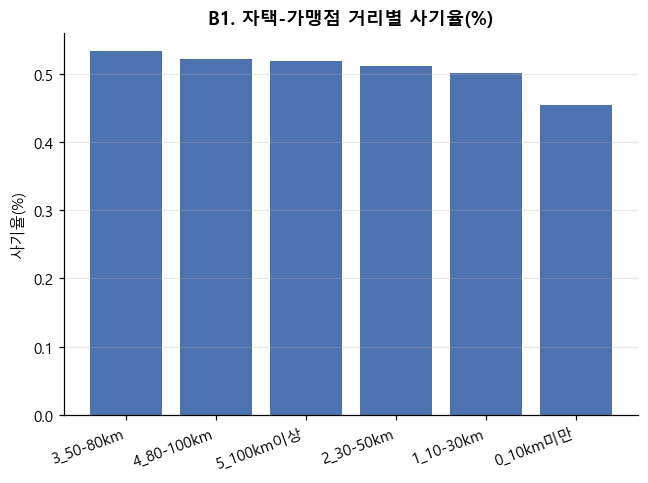

In [6]:
# B1. 자택-가맹점 거리
dist_km = haversine(df["lat"], df["long"], df["merch_lat"], df["merch_long"])
bins = [-1, 10, 30, 50, 80, 100, np.inf]
labels = ["0_10km미만", "1_10-30km", "2_30-50km", "3_50-80km", "4_80-100km", "5_100km이상"]
dist_bucket = pd.cut(dist_km, bins=bins, labels=labels)
tmp = pd.DataFrame({"dist_bucket": dist_bucket, "is_fraud": df["is_fraud"]})
t_b1 = fraud_table(tmp, ["dist_bucket"], min_count=1)
t_b1.to_csv(OUT_DIR / "B1_distance_fraud.csv", index=False, encoding="utf-8-sig")
print("[B1] 자택-가맹점 거리 구간별 사기율")
display(t_b1)
bar_chart(t_b1["dist_bucket"].astype(str), t_b1["fraud_pct"],
          "B1. 자택-가맹점 거리별 사기율(%)", "사기율(%)", OUT_DIR / "B1_distance_fraud.png", rotate=20)


[B3] 카드별 같은 날 최대 이동거리 구간별 사기(일) 비율


,span_bucket,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
2,2_150-300km,218376,1259,0.005765,0.5765,1.66
1,1_50-150km,174164,553,0.003175,0.3175,0.91
0,0_50km미만,161746,115,0.000711,0.0711,0.20


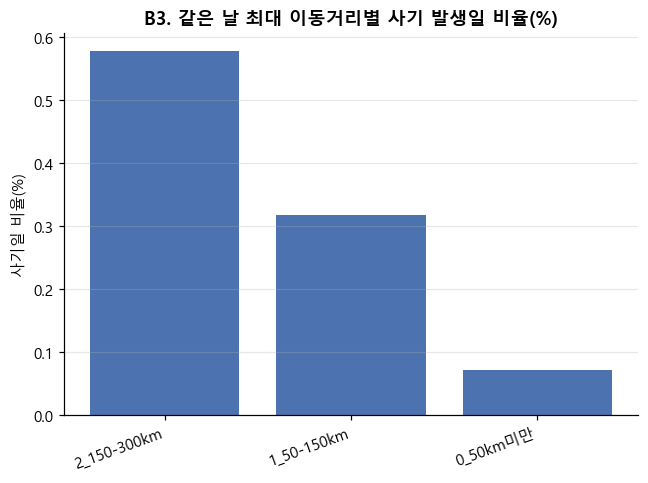

In [9]:
# B3. 카드별 같은 날 최대 이동거리
# 하루에 거래가 1건뿐인 카드-날짜 조합(전체의 80%+)은 무조건 0이므로, 그런
# 조합까지 매번 groupby.apply를 부르면 시간 대부분이 "계산"이 아니라
# pandas의 그룹당 함수호출 오버헤드로 날아간다. 하루 2건 이상인 조합에만
# combinations를 돌리면 실측 기준 약 5배 빠르다(280,001행: 85초 -> 16초.
# 185만 건 기준 체감 9~10분 -> 1~2분 수준).
def max_pairwise_dist(g: pd.DataFrame) -> float:
    pts = g[["merch_lat", "merch_long"]].to_numpy()
    best = 0.0
    for (i, j) in itertools.combinations(range(len(pts)), 2):
        d = haversine(pts[i, 0], pts[i, 1], pts[j, 0], pts[j, 1])
        if d > best:
            best = d
    return best

day_key = df["trans_date_trans_time"].dt.date
grp_all = df.groupby(["cc_num", day_key])
full_index = grp_all.size().index  # 모든 (cc_num, day) 조합

group_sizes = df.groupby(["cc_num", day_key])["trans_num"].transform("size")
multi_mask = group_sizes >= 2

span = pd.Series(0.0, index=full_index)
if multi_mask.any():
    span_multi = df.loc[multi_mask].groupby(["cc_num", day_key]).apply(
        max_pairwise_dist, include_groups=False
    )
    span.loc[span_multi.index] = span_multi.values

any_fraud = grp_all["is_fraud"].max()
span_df = pd.DataFrame({"max_dist_km": span, "any_fraud": any_fraud}).reset_index(drop=True)
span_bucket = pd.cut(
    span_df["max_dist_km"], bins=[-1, 50, 150, 300, np.inf],
    labels=["0_50km미만", "1_50-150km", "2_150-300km", "3_300km이상"],
)
tmp = pd.DataFrame({"span_bucket": span_bucket, "is_fraud": span_df["any_fraud"]})
t_b3 = fraud_table(tmp, ["span_bucket"], min_count=1)
t_b3.to_csv(OUT_DIR / "B3_same_day_span_fraud.csv", index=False, encoding="utf-8-sig")
print("[B3] 카드별 같은 날 최대 이동거리 구간별 사기(일) 비율")
display(t_b3)
bar_chart(t_b3["span_bucket"].astype(str), t_b3["fraud_pct"],
          "B3. 같은 날 최대 이동거리별 사기 발생일 비율(%)", "사기일 비율(%)",
          OUT_DIR / "B3_same_day_span_fraud.png", rotate=20)

## C. 가맹점 · 업종 다양성 패턴

- **C1**: 카드별 하루 이용 가맹점 수 (많을수록 위험한가 — "여기저기 찔러보는" 패턴)
- **C2**: 그 카드가 처음 써보는 가맹점인지 여부
- **C3**: 가맹점 자체의 사기 집중도 랭킹 (반복 침해 가맹점 후보)

[C1] 카드별 하루 이용 가맹점 수 구간별 사기(일) 비율


,merchant_cnt,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
7,8,13098,128,0.009772,0.9772,2.81
8,9,8419,81,0.009621,0.9621,2.77
6,7,20334,179,0.008803,0.8803,2.53
5,6,30371,260,0.008561,0.8561,2.46
4,5,45488,343,0.007540,0.7540,2.17
9,10,5416,32,0.005908,0.5908,1.70
3,4,65991,351,0.005319,0.5319,1.53
10,11,3499,18,0.005144,0.5144,1.48
14,15,663,2,0.003017,0.3017,0.87
2,3,92551,276,0.002982,0.2982,0.86


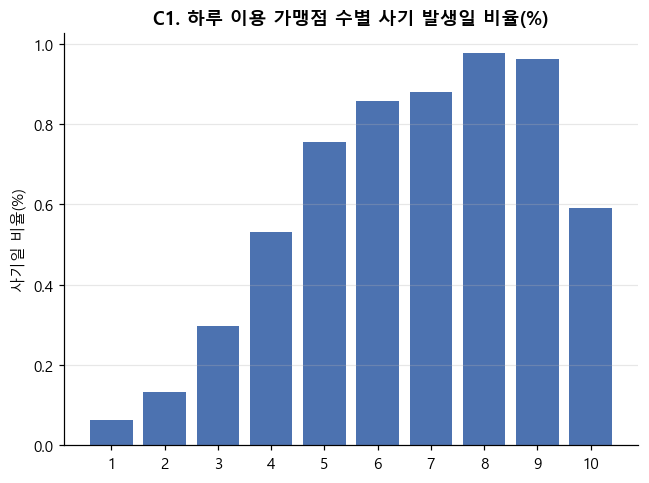

In [10]:
# C1. 카드별 하루 이용 가맹점 수
day_key = df["trans_date_trans_time"].dt.date
daily = df.groupby(["cc_num", day_key]).agg(
    merchant_cnt=("merchant", "nunique"),
    category_cnt=("category", "nunique"),
    any_fraud=("is_fraud", "max"),
).reset_index()
t_c1 = fraud_table(daily.rename(columns={"any_fraud": "is_fraud"}), ["merchant_cnt"], min_count=1)
t_c1.to_csv(OUT_DIR / "C1_daily_merchant_diversity_fraud.csv", index=False, encoding="utf-8-sig")
print("[C1] 카드별 하루 이용 가맹점 수 구간별 사기(일) 비율")
display(t_c1.head(10))
top = t_c1.sort_values("merchant_cnt").head(10)
bar_chart(top["merchant_cnt"].astype(str), top["fraud_pct"],
          "C1. 하루 이용 가맹점 수별 사기 발생일 비율(%)", "사기일 비율(%)",
          OUT_DIR / "C1_daily_merchant_diversity_fraud.png")


[C2] 가맹점 최초 이용 여부별 사기율


,novelty,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
1,최초이용,529328,4418,0.008346,0.8346,1.60
0,재이용,1323066,5233,0.003955,0.3955,0.76


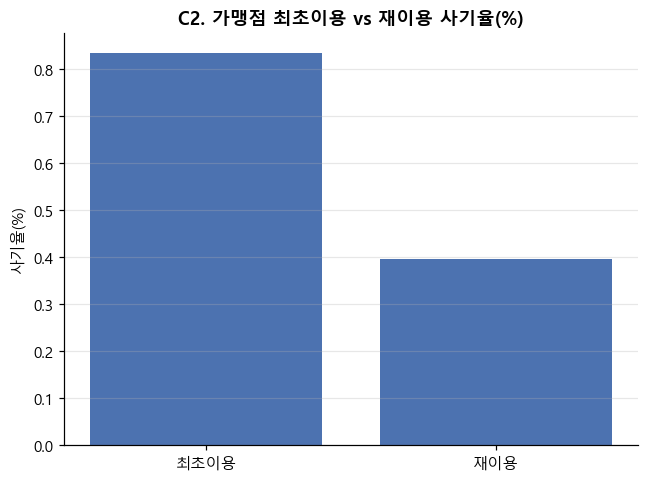

In [11]:
# C2. 가맹점 최초 이용 여부
rn = df.groupby(["cc_num", "merchant"]).cumcount() + 1
novelty = np.where(rn == 1, "최초이용", "재이용")
tmp = pd.DataFrame({"novelty": novelty, "is_fraud": df["is_fraud"]})
t_c2 = fraud_table(tmp, ["novelty"], min_count=1)
t_c2.to_csv(OUT_DIR / "C2_merchant_novelty_fraud.csv", index=False, encoding="utf-8-sig")
print("[C2] 가맹점 최초 이용 여부별 사기율")
display(t_c2)
bar_chart(t_c2["novelty"], t_c2["fraud_pct"], "C2. 가맹점 최초이용 vs 재이용 사기율(%)", "사기율(%)",
          OUT_DIR / "C2_merchant_novelty_fraud.png")


[C3] 가맹점별 사기율 TOP 15 (최소 20건)


,merchant,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
337,fraud_Kozey-Boehm,2758,60,0.021755,2.1755,4.18
245,"fraud_Herman, Treutel and Dickens",1870,38,0.020321,2.0321,3.90
616,fraud_Terry-Huel,2864,56,0.019553,1.9553,3.75
304,fraud_Kerluke-Abshire,2635,50,0.018975,1.8975,3.64
443,"fraud_Mosciski, Ziemann and Farrell",2821,53,0.018788,1.8788,3.61
555,"fraud_Schmeler, Bashirian and Price",2788,52,0.018651,1.8651,3.58
346,fraud_Kuhic LLC,2842,53,0.018649,1.8649,3.58
282,fraud_Jast Ltd,2757,51,0.018498,1.8498,3.55
372,"fraud_Langworth, Boehm and Gulgowski",2817,52,0.018459,1.8459,3.54
528,"fraud_Romaguera, Cruickshank and Greenholt",2767,51,0.018432,1.8432,3.54


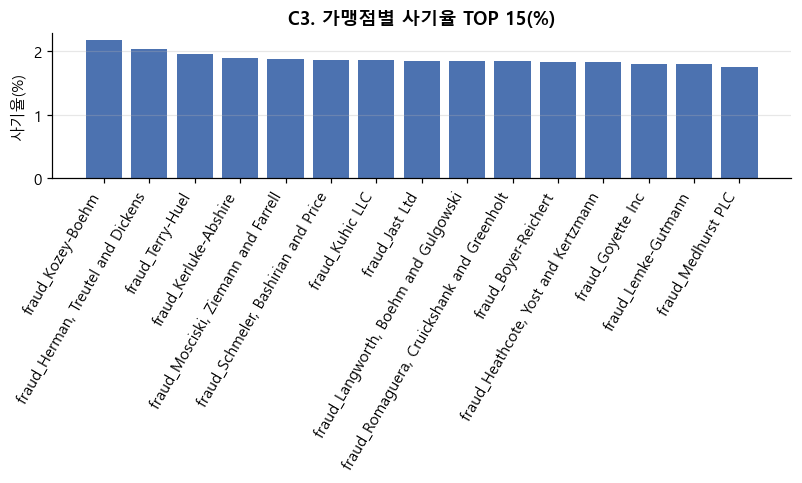

In [12]:
# C3. 가맹점별 사기율 랭킹 (최소 20건)
t_c3 = fraud_table(df, ["merchant"], min_count=20)
t_c3.to_csv(OUT_DIR / "C3_merchant_fraud_ranking.csv", index=False, encoding="utf-8-sig")
print("[C3] 가맹점별 사기율 TOP 15 (최소 20건)")
display(t_c3.head(15))
top3 = t_c3.head(15)
bar_chart(top3["merchant"], top3["fraud_pct"], "C3. 가맹점별 사기율 TOP 15(%)", "사기율(%)",
          OUT_DIR / "C3_merchant_fraud_ranking.png", rotate=60)


## D. 인구통계 패턴

- **D1**: 도시 인구밀도(city_pop) 구간별 — 도시 vs 농촌
- **D2**: 직업(job)별 사기율 랭킹 (합성 데이터는 직업이 1종류뿐이라 실제로는
  빈 결과일 수 있음 — 실데이터에서 의미가 생김)
- **D3**: 연령대 x 성별 x 업종 3중 코호트

[D1] 도시 인구밀도 구간별 사기율


,pop_bucket,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
3,3_중도시(10만-50만),161053,886,0.005501,0.5501,1.06
1,1_농촌(1천-1만),728320,3900,0.005355,0.5355,1.03
4,4_대도시(50만+),93737,498,0.005313,0.5313,1.02
2,2_소도시(1만-10만),300034,1550,0.005166,0.5166,0.99
0,0_초농촌(<1천),569250,2817,0.004949,0.4949,0.95


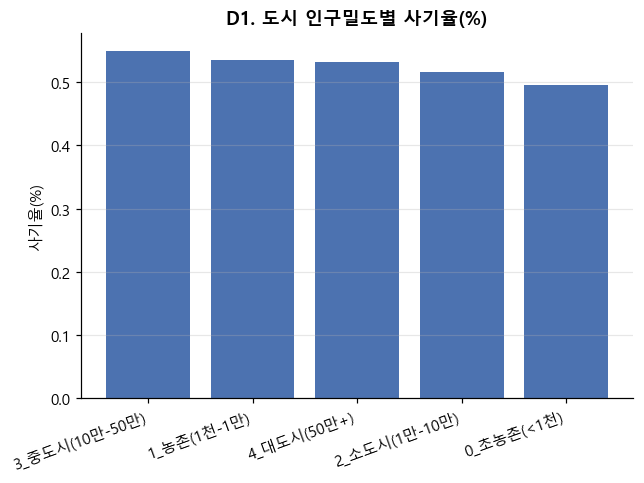

In [13]:
# D1. 도시 인구밀도
pop_bucket = pd.cut(
    df["city_pop"], bins=[-1, 1000, 10000, 100000, 500000, np.inf],
    labels=["0_초농촌(<1천)", "1_농촌(1천-1만)", "2_소도시(1만-10만)", "3_중도시(10만-50만)", "4_대도시(50만+)"],
)
tmp = pd.DataFrame({"pop_bucket": pop_bucket, "is_fraud": df["is_fraud"]})
t_d1 = fraud_table(tmp, ["pop_bucket"], min_count=1)
t_d1.to_csv(OUT_DIR / "D1_city_pop_fraud.csv", index=False, encoding="utf-8-sig")
print("[D1] 도시 인구밀도 구간별 사기율")
display(t_d1)
bar_chart(t_d1["pop_bucket"].astype(str), t_d1["fraud_pct"],
          "D1. 도시 인구밀도별 사기율(%)", "사기율(%)", OUT_DIR / "D1_city_pop_fraud.png", rotate=20)


In [14]:
# D2. 직업별 사기율 (최소 100건)
if df["job"].nunique() > 1:
    t_d2 = fraud_table(df, ["job"], min_count=100)
    t_d2.to_csv(OUT_DIR / "D2_job_fraud_ranking.csv", index=False, encoding="utf-8-sig")
    print("[D2] 직업별 사기율 TOP 15 (최소 100건)")
    display(t_d2.head(15))
else:
    print("[D2] 이 데이터는 job이 단일값이라 생략합니다. (실 raw 데이터에는 직업 다양성이 있습니다)")


[D2] 직업별 사기율 TOP 15 (최소 100건)


,job,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
448,TEFL teacher,760,32,0.042105,4.2105,8.08
263,Lawyer,757,28,0.036988,3.6988,7.10
98,Community development worker,751,22,0.029294,2.9294,5.62
2,"Accountant, chartered certified",751,21,0.027963,2.7963,5.37
229,Horticultural consultant,746,19,0.025469,2.5469,4.89
88,Clinical cytogeneticist,744,18,0.024194,2.4194,4.64
308,Nature conservation officer,743,16,0.021534,2.1534,4.13
211,"Geneticist, molecular",745,16,0.021477,2.1477,4.12
496,Writer,741,15,0.020243,2.0243,3.89
105,"Conservator, museum/gallery",743,15,0.020188,2.0188,3.87


In [15]:
# D3. 연령대 x 성별 x 업종
t_d3 = fraud_table(df, ["age_bucket", "gender", "category"], min_count=20)
t_d3.to_csv(OUT_DIR / "D3_age_gender_category_fraud.csv", index=False, encoding="utf-8-sig")
print("[D3] 연령대 x 성별 x 업종 사기율 TOP 15")
t_d3.head(15)


[D3] 연령대 x 성별 x 업종 사기율 TOP 15


,age_bucket,gender,category,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
4,~20대,F,grocery_pos,879,28,0.031854,3.1854,6.11
137,50대,M,shopping_net,9841,257,0.026115,2.6115,5.01
25,~20대,M,shopping_net,1924,45,0.023389,2.3389,4.49
165,60대+,M,shopping_net,12178,279,0.022910,2.2910,4.40
151,60대+,F,shopping_net,15042,333,0.022138,2.2138,4.25
123,50대,F,shopping_net,8273,183,0.022120,2.2120,4.25
81,30대,M,shopping_net,12800,274,0.021406,2.1406,4.11
53,20대,M,shopping_net,10328,208,0.020139,2.0139,3.87
18,~20대,M,grocery_pos,1016,20,0.019685,1.9685,3.78
148,60대+,F,misc_net,11295,221,0.019566,1.9566,3.76


## E. 금액의 절대적 형태 (개인 편차가 아닌 방식)

- **E1**: 라운드넘버 금액($10 단위, 정수) 여부 — 카드 유효성 테스트에 흔한 패턴
- **E2**: 직전 거래가 소액($5 미만)이고 5분 이내에 고액($200 이상) 거래가 오는
  "카드테스트 → 실사용" 시퀀스

[E1] 금액 형태별 사기율


,amt_shape,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
0,라운드(10의배수),1644,17,0.010341,1.0341,1.98
2,정수,16698,87,0.005210,0.5210,1.00
1,일반,1834052,9547,0.005205,0.5205,1.00


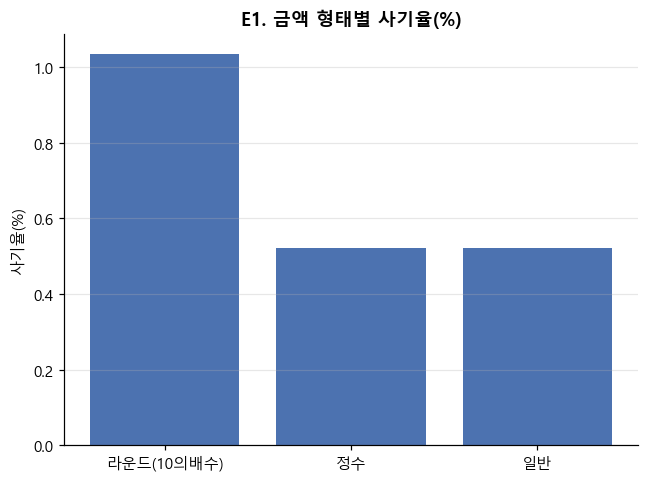

In [16]:
# E1. 금액 형태
is_round10 = (df["amt"] == np.floor(df["amt"])) & (np.mod(df["amt"], 10) == 0)
is_int = df["amt"] == np.floor(df["amt"])
amt_shape = np.select([is_round10, is_int & ~is_round10], ["라운드(10의배수)", "정수"], default="일반")
tmp = pd.DataFrame({"amt_shape": amt_shape, "is_fraud": df["is_fraud"]})
t_e1 = fraud_table(tmp, ["amt_shape"], min_count=1)
t_e1.to_csv(OUT_DIR / "E1_amt_shape_fraud.csv", index=False, encoding="utf-8-sig")
print("[E1] 금액 형태별 사기율")
display(t_e1)
bar_chart(t_e1["amt_shape"], t_e1["fraud_pct"], "E1. 금액 형태별 사기율(%)", "사기율(%)",
          OUT_DIR / "E1_amt_shape_fraud.png")


In [17]:
# E2. 카드테스트 의심 시퀀스
prev_amt = df.groupby("cc_num")["amt"].shift(1)
gap_sec = df.groupby("cc_num")["trans_date_trans_time"].diff().dt.total_seconds()
is_test_pattern = (prev_amt < 5) & (df["amt"] >= 200) & (gap_sec <= 300)
tmp = pd.DataFrame({
    "test_pattern": np.where(is_test_pattern, "카드테스트의심", "일반"),
    "is_fraud": df["is_fraud"],
})
t_e2 = fraud_table(tmp, ["test_pattern"], min_count=1)
t_e2.to_csv(OUT_DIR / "E2_card_test_pattern_fraud.csv", index=False, encoding="utf-8-sig")
print("[E2] 카드테스트 의심 패턴별 사기율")
t_e2


[E2] 카드테스트 의심 패턴별 사기율


,test_pattern,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
0,일반,1852188,9651,0.005211,0.5211,1.0
1,카드테스트의심,206,0,0.000000,0.0000,0.0


## F. 연속거래(짧은 시간창) 패턴

- **F1**: 직전 거래로부터 10분 이내에 다시 결제했는지 여부

[F1] 10분 이내 재결제 여부별 사기율


,rapid_repeat,tx_cnt,fraud_cnt,fraud_rate,fraud_pct,lift_vs_overall
0,10분이내재결제,60892,1162,0.019083,1.9083,3.66
1,아님,1791502,8489,0.004738,0.4738,0.91


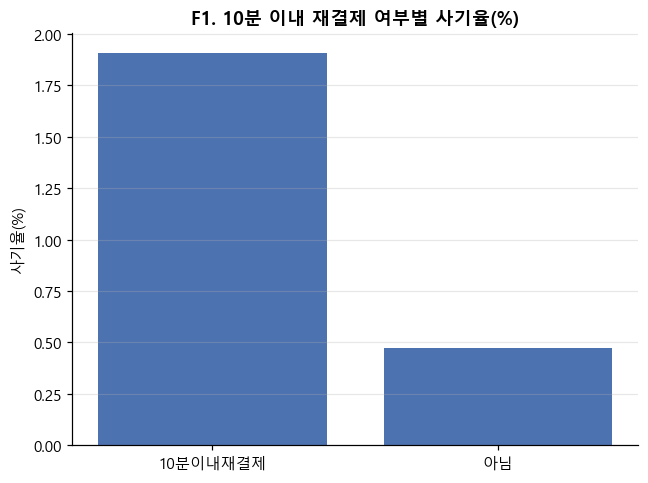

In [18]:
gap_sec = df.groupby("cc_num")["trans_date_trans_time"].diff().dt.total_seconds()
rapid = np.where(gap_sec.notna() & (gap_sec <= 600), "10분이내재결제", "아님")
tmp = pd.DataFrame({"rapid_repeat": rapid, "is_fraud": df["is_fraud"]})
t_f1 = fraud_table(tmp, ["rapid_repeat"], min_count=1)
t_f1.to_csv(OUT_DIR / "F1_rapid_repeat_fraud.csv", index=False, encoding="utf-8-sig")
print("[F1] 10분 이내 재결제 여부별 사기율")
display(t_f1)
bar_chart(t_f1["rapid_repeat"], t_f1["fraud_pct"], "F1. 10분 이내 재결제 여부별 사기율(%)", "사기율(%)",
          OUT_DIR / "F1_rapid_repeat_fraud.png")


## 정리

`new_pattern_eda_outputs/` 폴더에 저장된 csv/png를 훑어보면서, 사기율 lift가 뚜렷하게
튀는 축(=lift_vs_overall이 1.5~2배 이상인 구간)을 골라내면 된다. 그런 축이 있다면:

1. 그 축을 새 파생변수로 만들어서(예: `same_day_max_dist_km`, `is_first_merchant`,
   `gap_sec_since_prev`) 11개 변수 세트에 추가 실험해볼 수 있다.
2. 다만 여기서도 **데이터 누수 원칙은 동일**하게 지켜야 한다 — 예를 들어
   "카드별 같은 날 최대 이동거리"를 변수로 쓰려면, 하루가 끝나야 알 수 있는 값이므로
   그 날의 마지막 거래 시점까지는 실시간으로 알 수 없다는 점을 고려해서 "그 거래
   이전까지의 오늘자 최대 이동거리"처럼 시점을 인과적으로 다시 정의해야 한다.
   지금 이 노트북은 탐색용이라 그 제약 없이 계산했다.
